## Data pre-processing

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('./dataset/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Checking for class imbalancing because depending on the answer the right metric would need to be chosen in order to measure the models performences

In [6]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [7]:
df["y_binary"] = df["y"].map({"no": 0, "yes": 1})

In [8]:
X_classification_raw = df.drop(columns=["y", "y_binary", "duration"])
y_classification = df["y_binary"]

X_regression_raw = df.drop(columns=["y", "y_binary", "duration"])
y_regression = df["duration"]

In [9]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous      y_binary  
count  45211.000000  45211.000000  45211.000000  
mean      40.197828      0.580323      0.116985  
std      100.128746      2.303441      0.321406  
min       -1.000000      0.000000      0.000000  
25%       -1.000000      0.00

In [10]:
'''
    Instead all categorical features having k columns each now they will contain k-1 columns hence reducing k columns from the 
    respective encoding transformation dataset (this is because drop_first=True)
'''
X_classification = pd.get_dummies(X_classification_raw, drop_first=True)
X_regression = pd.get_dummies(X_regression_raw, drop_first=True)

In [11]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

In [12]:
print("Classification training data:", X_train_cls.shape)
print("Classification testing data:", X_test_cls.shape)

print("Regression training data:", X_train_reg.shape)
print("Regression testing data:", X_test_reg.shape)

Classification training data: (36168, 41)
Classification testing data: (9043, 41)
Regression training data: (36168, 41)
Regression testing data: (9043, 41)


### Choices behind Data pre-processing

The dataset was first loaded and inspected to understand its structure, the data types of each variable, and whether any missing values were present. The output of `df.info()` showed that every column contained 45,211 non-null values, meaning that no missing values were detected by pandas. Therefore, no missing-value imputation was required at this stage.

I also checked the distribution of the target variable `y` using normalised proportions. This was done to identify whether the classification problem is imbalanced. This is important because, depending on whether the dataset is balanced or imbalanced, different evaluation metrics may be needed to properly measure the performance of the classification models.

The target variable `y` was label encoded by mapping `no` to 0 and `yes` to 1. This is appropriate because `y` is the binary output variable that the classification models need to predict. This is different from label encoding categorical input features, because the target variable is used as the class label, whereas input features are used by the model to learn patterns. If unordered categorical input features were label encoded, the model could incorrectly treat the assigned numbers as having a meaningful order.

For the input features, the categorical variables were encoded using one-hot encoding. This was chosen because most categorical variables in the dataset, such as `job`, `marital`, `education`, `contact`, `month`, and `poutcome`, do not have a natural numerical order. Using simple integer label encoding for these variables could incorrectly imply an artificial ranking between categories, such as one job type being greater than another. One-hot encoding avoids this problem by representing each category using binary 0/1 columns.

Furthermore, numerical variables such as `age`, `balance`, `campaign`, `pdays`, and `previous` already have meaningful numerical values. Therefore, they were not converted into dummy categories, and their original numerical form was kept.

## Interpreting White-Box Models

### Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import StandardScaler

In [14]:
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

numeric_features = ["age", "balance", "day", "campaign", "pdays", "previous"]

scaler = StandardScaler()

X_train_reg_scaled[numeric_features] = scaler.fit_transform(X_train_reg[numeric_features])

X_test_reg_scaled[numeric_features] = scaler.transform(X_test_reg[numeric_features])

In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train_reg_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred_reg = linear_model.predict(X_test_reg_scaled)

In [17]:
mae = MAE(y_test_reg, y_pred_reg)
mse = MSE(y_test_reg, y_pred_reg)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

Mean Absolute Error: 171.29869402805
Mean Squared Error: 66840.14334129303


In [18]:
coefficients = pd.DataFrame({"Feature": X_train_reg_scaled.columns, "Coefficient": linear_model.coef_})
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients_sorted = coefficients.sort_values(by="Absolute_Coefficient",ascending=False)

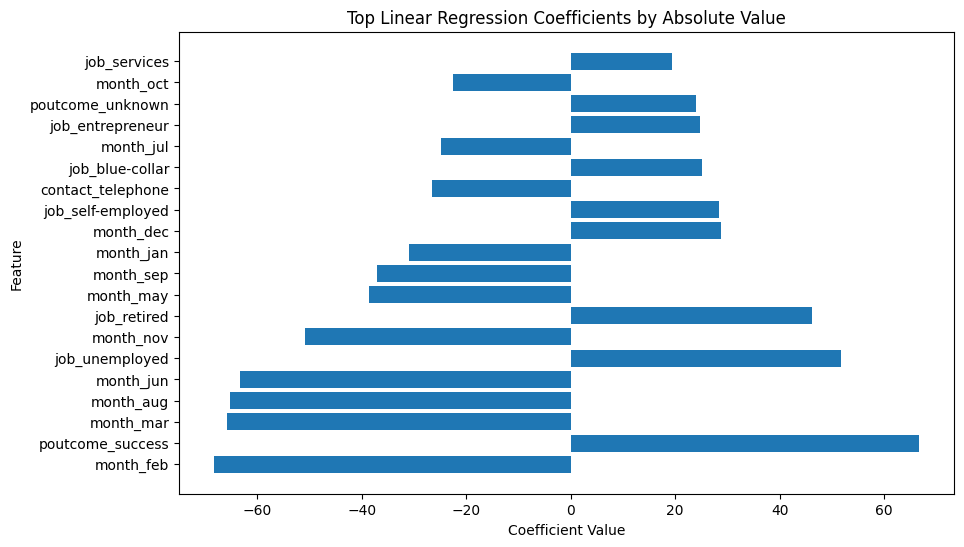

In [19]:
top_coefficients = coefficients_sorted.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Linear Regression Coefficients by Absolute Value")
plt.show()

#### Model Building Choices

The Linear Regression model was trained to predict the continuous target variable `duration`, which represents the length of the marketing phone call. Since `duration` is a continuous numerical variable, Linear Regression is suitable because it predicts a continuous output using a weighted combination of the explanatory variables.

Before fitting the model, the numerical explanatory variables were standardised because variables such as `balance`, `age`, `campaign`, `pdays`, and `previous` have different numerical ranges. Scaling these numerical variables makes their coefficient magnitudes more comparable. The one-hot encoded categorical variables were kept as 0/1 values so that their interpretation remains clear. For example, `job_retired = 1` means that the client belongs to the retired job category, while `job_retired = 0` means that the client does not belong to that category.

The model was also evaluated using MAE and MSE as a brief check of its prediction error. The MAE was 171.30, meaning that, on average, the predicted call duration differed from the actual duration by around 171 seconds. The MSE was 66840.14, which gives stronger penalty to larger prediction errors. These values suggest that the Linear Regression model gives only a limited prediction model for call duration. Call duration is likely influenced by more complex factors, interactions between variables, or information that is not available in the dataset. Therefore, the main purpose of this model is not to produce highly accurate duration predictions, but to interpret the learned coefficients and understand how the features are associated with the predicted duration.

#### Linear Regression Coefficient Interpretation

To interpret the Linear Regression model, I examined the learned coefficient values. Since the target variable is `duration`, the coefficients show how each feature is associated with the predicted call duration, measured in seconds. A positive coefficient means that the feature is associated with a higher predicted duration, while a negative coefficient means that the feature is associated with a lower predicted duration, holding the other variables fixed.

The plot shows the 20 features with the largest absolute coefficient values. I selected the top 20 rather than plotting all coefficients because one-hot encoding created many feature columns, especially from categorical variables such as `job`, `month`, `education`, and `poutcome`. If all coefficients were shown, the plot would become crowded and difficult to interpret. Therefore, the plot is used to provide clear examples of how the model’s coefficients relate features to the predicted output.

The coefficients are sorted by absolute value so that both large positive and large negative relationships are included. This is important because a large negative coefficient can be just as important to discuss as a large positive coefficient. The sign of the coefficient is then used to interpret the direction of the relationship: positive coefficients are associated with higher predicted duration, while negative coefficients are associated with lower predicted duration, holding the other variables fixed.

Among the displayed coefficients, `poutcome_success` has the largest positive coefficient, suggesting that clients whose previous campaign outcome was successful are associated with longer predicted call durations compared with the reference `poutcome` category. Other positive coefficients, such as `job_unemployed`, `job_retired`, `job_self-employed`, `job_blue-collar`, and `job_entrepreneur`, suggest that these job categories are also associated with longer predicted durations compared with the reference job category.

Among the displayed coefficients, the large negative coefficients are mainly month-related variables, such as `month_feb`, `month_mar`, `month_aug`, `month_jun`, `month_nov`, and `month_may`. This suggests that calls made during these months are associated with shorter predicted call durations compared with the reference month. The negative coefficient for `contact_telephone` also suggests that telephone contact is associated with shorter predicted duration compared with the reference contact category.

Since most of these features are one-hot encoded categorical variables, their coefficients are interpreted relative to the dropped reference category. These coefficients should not be interpreted as causal effects. They describe associations learned by the fitted Linear Regression model. Also, because the model had relatively high prediction error, these coefficient values should be treated as rough linear associations rather than precise explanations of call duration.

### Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
X_train_cls_scaled = X_train_cls.copy()
X_test_cls_scaled = X_test_cls.copy()

numeric_features = ["age", "balance", "day", "campaign", "pdays", "previous"]

scaler = StandardScaler()

X_train_cls_scaled[numeric_features] = scaler.fit_transform(X_train_cls[numeric_features])

X_test_cls_scaled[numeric_features] = scaler.transform(X_test_cls[numeric_features])

In [22]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_cls_scaled, y_train_cls)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred_log = logistic_model.predict(X_test_cls_scaled)

In [24]:
conf_matrix = confusion_matrix(y_test_cls, y_pred_log)
conf_matrix_df = pd.DataFrame(conf_matrix, index=["Actual No", "Actual Yes"], columns=["Predicted No", "Predicted Yes"])
conf_matrix_df

,Predicted No,Predicted Yes
Actual No,7891,94
Actual Yes,871,187


In [25]:
logistic_coefficients = pd.DataFrame({"Feature": X_train_cls.columns, "Coefficient": logistic_model.coef_[0]})

logistic_coefficients["Odds_Ratio"] = np.exp(logistic_coefficients["Coefficient"]) #since the coefficients are in log-odds, we can exponentiate them to get the odds ratio
logistic_coefficients["Absolute_Coefficient"] = logistic_coefficients["Coefficient"].abs()

logistic_coefficients_sorted = logistic_coefficients.sort_values(by="Absolute_Coefficient", ascending=False)
top_logistic_coefficients = logistic_coefficients_sorted.head(20)
top_logistic_coefficients

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
39,poutcome_success,2.253131,9.517484,2.253131
26,contact_unknown,-1.320791,0.266924,1.320791
30,month_jan,-1.108964,0.329900,1.108964
33,month_mar,0.993410,2.700428,0.993410
35,month_nov,-0.889959,0.410673,0.889959
27,month_aug,-0.862338,0.422174,0.862338
31,month_jul,-0.724504,0.484565,0.724504
37,month_sep,0.615183,1.849995,0.615183
28,month_dec,0.592625,1.808730,0.592625
36,month_oct,0.592152,1.807874,0.592152


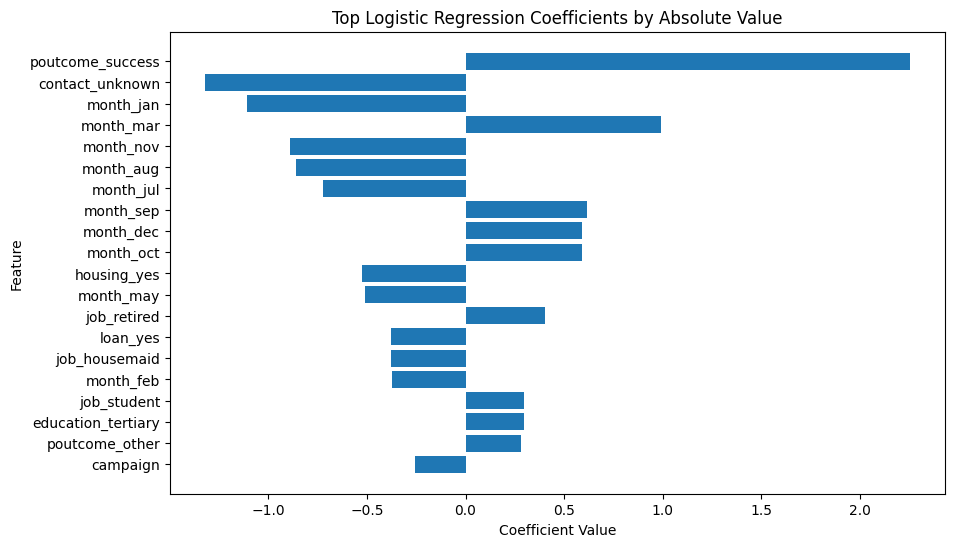

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(top_logistic_coefficients["Feature"], top_logistic_coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients by Absolute Value")
plt.gca().invert_yaxis()
plt.show()

#### Model Building Choices

The Logistic Regression model was trained to predict whether a client subscribed to a term deposit. Since this is a binary classification problem, the model estimates the probability of the positive class, `y = yes`.

Before fitting the model, the numerical explanatory variables were standardised because variables such as `balance`, `age`, `campaign`, `pdays`, and `previous` have different numerical ranges. Scaling these variables helps the Logistic Regression model train more reliably. The one-hot encoded categorical variables were kept as 0/1 values so that their interpretation remains clear. For example, `housing_yes = 1` means that the client has a housing loan, while `housing_yes = 0` means that the client does not have a housing loan.

A confusion matrix was also generated as a brief check of the model’s prediction behaviour. However, since the main aim of this task is to interpret the Logistic Regression coefficients, the main discussion focuses on the coefficient values and odds ratios rather than on the evaluation metrics.

#### Logistic Regression Coefficient Interpretation

To interpret the Logistic Regression model, I examined the learned coefficient values and their corresponding odds ratios. Since Logistic Regression predicts a binary output, the model estimates the probability of the positive class, where `y = yes` means that the client subscribed to a term deposit.

The coefficients are not interpreted directly as changes in probability. Instead, Logistic Regression coefficients are interpreted on the log-odds scale. A positive coefficient increases the log-odds of predicting `y = yes`, while a negative coefficient decreases the log-odds of predicting `y = yes`, holding the other variables fixed. Since the logistic function converts log-odds into probabilities, positive coefficients push the model towards a higher probability of subscription, while negative coefficients push the model towards a lower probability of subscription.

The coefficient table and plot show the 20 features with the largest absolute coefficient values. I visualised the top 20 rather than all coefficients because one-hot encoding created many feature columns, especially from categorical variables such as `job`, `month`, `education`, `contact`, and `poutcome`. Showing all coefficients would make the graph crowded and difficult to interpret. Therefore, the displayed coefficients are used as clear examples of how positive and negative Logistic Regression coefficients affect the prediction of `y = yes`.

Among the displayed coefficients, `poutcome_success` has the largest positive coefficient. Its coefficient is approximately `2.253`, with an odds ratio of approximately `9.52`. This means that, compared with the reference `poutcome` category, clients whose previous campaign outcome was successful have much higher odds of being predicted as `y = yes`, holding the other variables fixed. Since this coefficient is positive, it pushes the model towards a higher probability of predicting subscription.

Other positive coefficients include `month_mar`, `month_sep`, `month_dec`, `month_oct`, `job_retired`, `job_student`, `education_tertiary`, and `poutcome_other`. These features are associated with higher odds of predicting `y = yes`. For example, `month_mar` has an odds ratio of approximately `2.70`, meaning that contacts made in March are associated with higher odds of subscription compared with the reference month. Similarly, `job_retired` and `job_student` have odds ratios greater than 1, meaning that these job categories push the model more towards predicting `y = yes` compared with the reference job category.

The strongest negative coefficient is `contact_unknown`. Its coefficient is approximately `-1.321`, with an odds ratio of approximately `0.27`. This means that, compared with the reference contact category, clients with an unknown contact method have much lower odds of being predicted as `y = yes`, holding the other variables fixed. Since this coefficient is negative, it pushes the model towards a lower probability of predicting subscription.

Other negative coefficients include `month_jan`, `month_nov`, `month_aug`, `month_jul`, `housing_yes`, `month_may`, `loan_yes`, `job_housemaid`, `month_feb`, and `campaign`. These features are associated with lower odds of predicting `y = yes`. For example, `housing_yes` has an odds ratio of approximately `0.59`, meaning that clients with a housing loan have lower odds of being predicted as subscribers compared with clients in the reference housing category. Similarly, `loan_yes` has an odds ratio below 1, suggesting that clients with a personal loan are associated with lower odds of subscription. The negative coefficient for `campaign` also suggests that a higher number of contacts during the current campaign is associated with lower odds of predicting `y = yes`.

The odds ratios make the coefficient interpretation clearer. An odds ratio greater than 1 means that the feature increases the odds of predicting `y = yes`, while an odds ratio less than 1 means that the feature decreases the odds of predicting `y = yes`. For one-hot encoded categorical variables, this comparison is made relative to the dropped reference category. Therefore, the coefficient sign shows the direction of the relationship, while the odds ratio gives a more interpretable measure of how strongly the odds change.

Overall, the Logistic Regression model suggests that previous campaign success is the strongest positive indicator among the displayed coefficients, while unknown contact method is the strongest negative indicator. The model also uses campaign timing, financial obligations, job category, education level, and previous campaign outcome when estimating the probability of `y = yes`. However, these results should be interpreted as associations learned by the fitted model, not as causal effects. Coefficient magnitudes should also be interpreted carefully because they can be affected by feature scale, reference categories, and possible collinearities between explanatory variables.

### Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
decision_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

decision_tree_model.fit(X_train_cls, y_train_cls)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [29]:
y_pred_tree = decision_tree_model.predict(X_test_cls)

In [30]:
tree_conf_matrix = confusion_matrix(y_test_cls, y_pred_tree)

tree_conf_matrix_df = pd.DataFrame(tree_conf_matrix, index=["Actual No", "Actual Yes"], columns=["Predicted No", "Predicted Yes"])

tree_conf_matrix_df

,Predicted No,Predicted Yes
Actual No,7892,93
Actual Yes,873,185


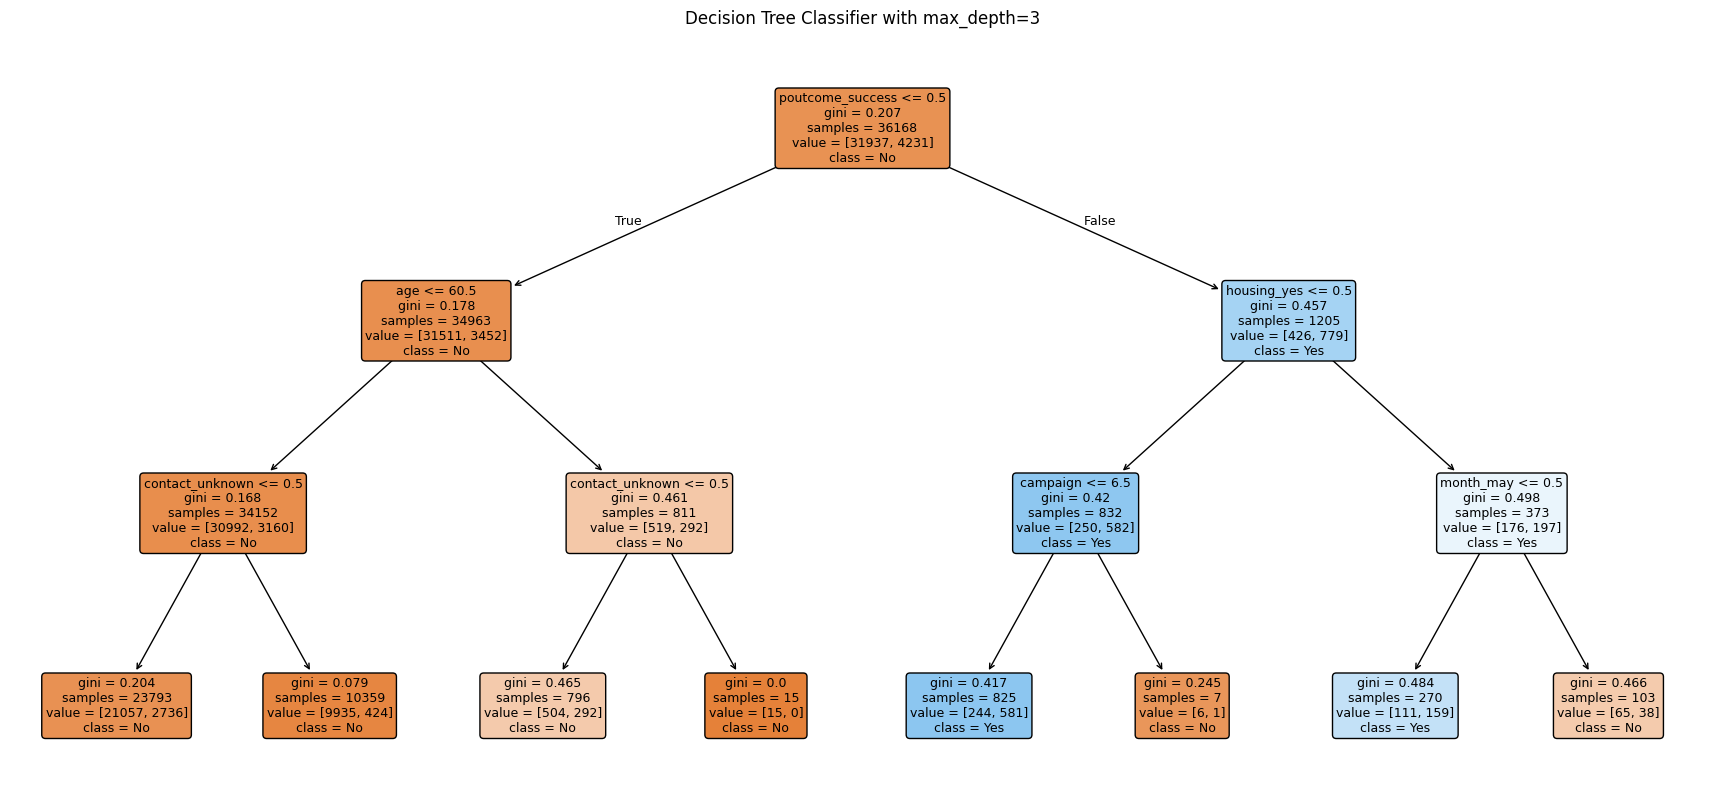

In [31]:
plt.figure(figsize=(22, 10))

plot_tree(
    decision_tree_model,
    feature_names=X_train_cls.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier with max_depth=3")
plt.show()

In [32]:
tree_feature_importance = pd.DataFrame({"Feature": X_train_cls.columns, "Importance": decision_tree_model.feature_importances_})

tree_feature_importance = tree_feature_importance.sort_values(by="Importance", ascending=False)

top_tree_features = tree_feature_importance.head(10)

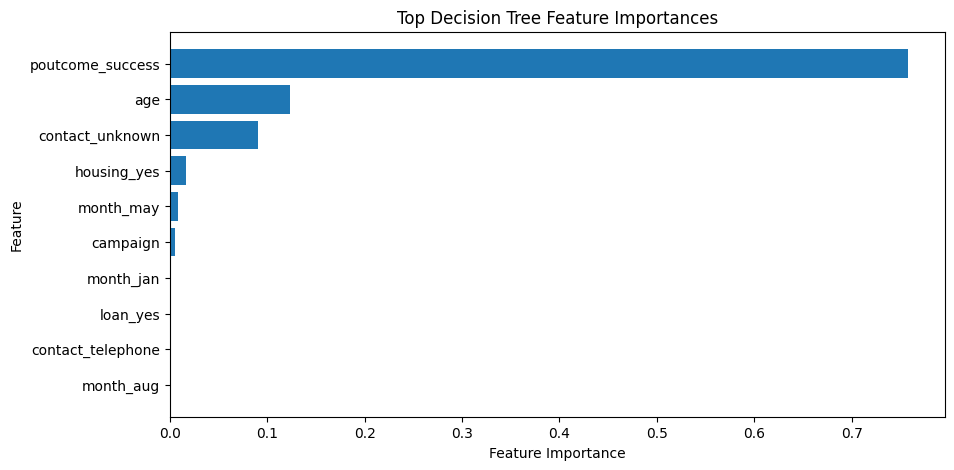

In [33]:
plt.figure(figsize=(10, 5))
plt.barh(top_tree_features["Feature"], top_tree_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Decision Tree Feature Importances")
plt.gca().invert_yaxis()
plt.show()

#### Model Building Choices

The Decision Tree classifier was trained to predict whether a client subscribed to a term deposit, where the target variable is `y`. The same classification feature set was used as in the Logistic Regression model, meaning that `duration` was not included as an explanatory variable when predicting `y`.

The model was trained using the preprocessed classification data, where the categorical variables had already been converted into one-hot encoded features. This means that categorical values such as `poutcome_success`, `housing_yes`, `contact_unknown`, and `month_may` are represented as binary 0/1 columns. This is useful for the Decision Tree because it can split on these binary features and check whether a specific category is present or not.

Unlike Logistic Regression, the Decision Tree did not require feature scaling. This is because Decision Trees make decisions by splitting the data using threshold-based rules, rather than by learning coefficients through an optimisation process. Therefore, numerical variables such as `age` and `campaign` can be used directly, and one-hot encoded variables can remain as 0/1 values.

After fitting the model, predictions were made on the test set and a confusion matrix was generated as a brief check of the model’s prediction behaviour. The main interpretation, however, comes from visualising the tree itself and examining the features used in the decision rules. I also extracted the feature importance values to identify which features were used most by the tree when splitting the data.

#### Decision Tree Interpretation

The Decision Tree makes its prediction by following a sequence of feature-based rules from the root node to a leaf node. Each internal node checks a condition on a feature, each branch represents the result of that condition, and each leaf gives the final predicted class.

The first split of the tree is on `poutcome_success`, meaning that the model first separates clients based on whether the previous campaign outcome was successful. Since this feature is one-hot encoded, `poutcome_success <= 0.5` means that the previous campaign outcome was not successful, while `poutcome_success > 0.5` means that the previous campaign outcome was successful.

On the left side of the tree, where `poutcome_success <= 0.5`, most clients are predicted as `No`. This means that if the client did not have a previous successful campaign outcome, the model generally predicts that the client will not subscribe. The tree then refines this decision using `age` and `contact_unknown`. For clients without previous campaign success, the model checks whether `age <= 60.5`, and then checks whether the contact method is unknown. However, most of these paths still end in a `No` prediction, showing that the absence of previous campaign success strongly routes the tree towards predicting non-subscription.

On the right side of the tree, where `poutcome_success > 0.5`, the model is more likely to predict `Yes`. This means that previous campaign success is strongly associated with subscription in the fitted tree. The model then checks `housing_yes`, which represents whether the client has a housing loan. If `housing_yes <= 0.5`, meaning the client does not have a housing loan, the tree then checks `campaign <= 6.5`. This path mostly leads to a `Yes` prediction. This suggests that clients with previous campaign success, no housing loan, and a lower number of contacts in the current campaign are more likely to be classified as subscribers.

The tree also uses `month_may` on one of the right-side paths. Since `month_may` is one-hot encoded, `month_may <= 0.5` means that the contact month was not May, while `month_may > 0.5` means that the contact month was May. In this part of the tree, the model predicts `Yes` when the contact was not in May, but predicts `No` when the contact was in May. This suggests that, within this branch of the tree, the month of contact helps refine the final decision.

The feature importance plot supports the decision paths shown in the tree. The most important feature is clearly `poutcome_success`, which matches the tree visualisation because it is used at the root node. This means it is the first feature used to route clients into the two main branches: clients without previous campaign success mostly move towards `No`, while clients with previous campaign success move towards branches where `Yes` is more likely.

The next most important features are `age` and `contact_unknown`, which also appear on the left side of the tree. These features are used to refine the prediction for clients whose previous campaign outcome was not successful. On the right side of the tree, `housing_yes`, `campaign`, and `month_may` are used to refine the prediction for clients whose previous campaign outcome was successful. Therefore, the feature importance plot confirms that the most important features are the same features used in the visible decision paths.

The `gini` values shown in the tree describe how mixed each node is. A lower Gini value means the node is more pure, meaning it mostly contains one class. The `value` field shows the number of training examples from each class at that node, where the first number corresponds to `No` and the second corresponds to `Yes`. The final `class` shown in each node is the majority class at that point, which becomes the prediction if the path ends at that leaf.

Overall, the Decision Tree makes its decisions by first checking whether the previous campaign outcome was successful. If not, the model mostly predicts `No`, while using `age` and `contact_unknown` to refine the decision. If the previous campaign outcome was successful, the model is more likely to predict `Yes`, and then uses `housing_yes`, `campaign`, and `month_may` to refine the prediction. Therefore, the tree’s decisions are mainly based on previous campaign outcome, age, contact method, housing loan status, campaign contact count, and contact month.

## Interpreting Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

random_forest_model.fit(X_train_cls, y_train_cls)
#no need to scale the data for Random Forests, because tree-based models split using thresholds and are not sensitive to feature scale in the same way as Logistic Regression.

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf = random_forest_model.predict(X_test_cls)

In [37]:
rf_conf_matrix = confusion_matrix(y_test_cls, y_pred_rf)

rf_conf_matrix_df = pd.DataFrame(rf_conf_matrix, index=["Actual No", "Actual Yes"], columns=["Predicted No", "Predicted Yes"])
rf_conf_matrix_df

,Predicted No,Predicted Yes
Actual No,7856,129
Actual Yes,821,237


In [38]:
rf_feature_importance = pd.DataFrame({"Feature": X_train_cls.columns, "Importance": random_forest_model.feature_importances_})

rf_feature_importance = rf_feature_importance.sort_values(by="Importance", ascending=False)
top_rf_features = rf_feature_importance.head(20)

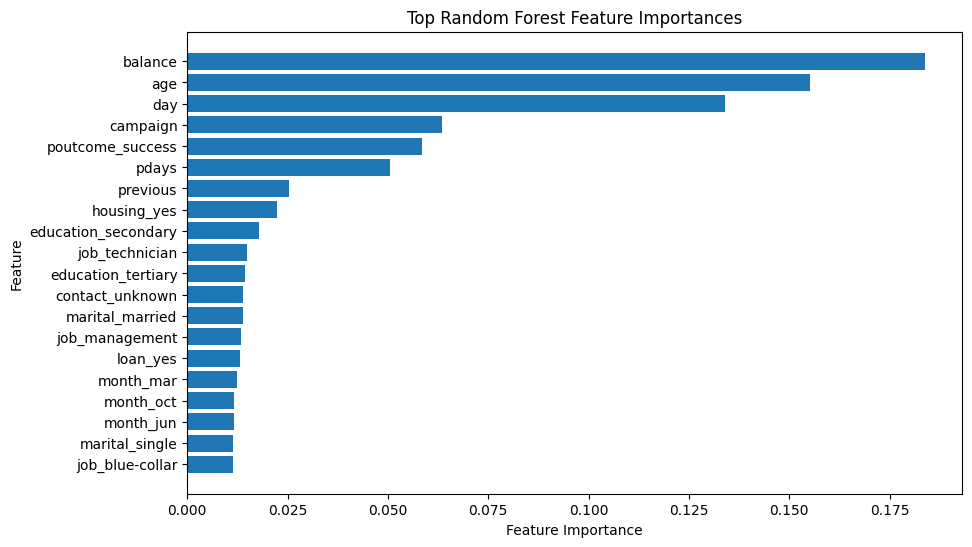

In [39]:
plt.figure(figsize=(10, 6))
plt.barh(top_rf_features["Feature"], top_rf_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

#### Random Forest: Model Building Choices

Unlike Logistic Regression, the Random Forest did not require feature scaling. This is because Random Forests are made up of decision trees, which make predictions by applying threshold-based splits rather than by learning coefficients through optimisation. Therefore, numerical variables such as `balance`, `age`, `day`, and `campaign` could be used directly, while one-hot encoded categorical variables remained as 0/1 columns.

After fitting the model, feature importance values were extracted from the trained Random Forest. These importance values were used to rank the features according to how useful they were across the trees when predicting the target variable.

#### Random Forest Feature Importance Interpretation

The Random Forest classifier was interpreted using feature importance. Since a Random Forest is made up of many decision trees, there is no single decision path to follow like there is with one Decision Tree. Instead, feature importance gives a global ranking of the variables that were most useful across all trees when predicting the target variable `y`.

The plot shows the top Random Forest feature importances. A higher feature importance value means that the feature was more useful for splitting the data and reducing impurity across the trees in the forest. Therefore, the most important features are the ones that the Random Forest relied on most when separating clients who subscribed from those who did not subscribe.

The most important feature is `balance`, with an importance value of approximately 0.184. This suggests that the client’s account balance was the most informative feature used by the Random Forest when predicting whether the client subscribed to a term deposit. The next most important features are `age` and `day`, with importance values of approximately 0.155 and 0.134. This means that the model also relied strongly on the client’s age and the day of contact when making predictions.

Other important features include `campaign`, `poutcome_success`, `pdays`, and `previous`. These features are related to the marketing campaign and previous contact history. For example, `campaign` represents the number of contacts performed during the current campaign, while `poutcome_success` indicates whether the previous campaign outcome was successful. Their relatively high importance values suggest that the Random Forest found campaign behaviour and previous campaign information useful for predicting subscription.

The plot also shows that features such as `housing_yes`, `education_secondary`, `job_technician`, `education_tertiary`, `contact_unknown`, `marital_married`, and `loan_yes` have lower but still visible importance. This means that these features contributed to the model’s predictions, but less strongly than the top features such as `balance`, `age`, and `day`.

Overall, the Random Forest feature importance ranking suggests that the model mainly uses client financial information, client demographic information, timing of contact, and campaign history to predict whether a client subscribes. However, feature importance should be interpreted carefully. It tells us which features were useful for prediction at a global level, but it does not tell us whether a feature increases or decreases the probability of `y = yes`. It also does not prove that a feature causes subscription. Therefore, `balance` being the most important feature means that it was highly useful for the Random Forest when making predictions, not that balance directly causes a client to subscribe.

## Permutation feature importance

In [40]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Before applying Permutation Feature Importance, I checked for strong correlations between explanatory variables because PFI can be affected when features contain overlapping information. Using a threshold of 0.65 allowed me to inspect feature pairs that were close to a strong correlation level.

In [41]:
corr_matrix = X_train_cls.corr().abs()

#Keeping only the upper triangle to avoid duplicate pairs
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#Converting correlation matrix into a table of feature pairs
high_corr_pairs = upper_triangle.stack().reset_index()
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

#Selecting strongly correlated pairs only
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > 0.65]

#Sorting from strongest to weakest correlation
high_corr_pairs = high_corr_pairs.sort_values(by="Correlation", ascending=False)

high_corr_pairs

,Feature_1,Feature_2,Correlation
189,pdays,poutcome_unknown,0.870425
544,marital_married,marital_single,0.772118
589,education_secondary,education_tertiary,0.660828


The strongest correlation was between `pdays` and `poutcome_unknown`, with a correlation of approximately 0.87. This suggests that these two variables may contain related information about previous campaign contact history. Therefore, the PFI results for these variables should be interpreted carefully, because permuting one of them may not fully remove the information if the other correlated feature still carries a similar signal.

The other correlated pairs, such as `marital_married` with `marital_single` and `education_secondary` with `education_tertiary`, are one-hot encoded categories from the same original categorical variables. These correlations are partly caused by the dummy encoding structure, since one client cannot belong to multiple categories of the same variable at the same time. Therefore, these were not treated as redundant features to remove.

Since only `pdays` and `poutcome_unknown` showed a correlation above 0.80, I kept the feature set unchanged and applied PFI directly to the trained Random Forest, while considering this correlation when interpreting the results.

In [42]:
pfi_result = permutation_importance(random_forest_model, X_test_cls, y_test_cls, n_repeats=10, random_state=42, scoring="f1")

Since the target variable is imbalanced, with approximately 88.3% `no` cases and 11.7% `yes` cases, I used F1-score rather than accuracy when computing Permutation Feature Importance. Accuracy could be misleading because a model can achieve high accuracy by mostly predicting the majority class. F1-score is more suitable here because it considers both precision and recall for the positive class, `y = yes`.

For Permutation Feature Importance, I used the repeated random shuffling approach. This means that each feature was randomly permuted several times, and the average decrease in model performance was used as the feature importance value. This approach was chosen because it gives more stable importance estimates than a single shuffle without requiring the very large dataset expansion of the exhaustive permutation approach.

In [43]:
pfi_importance = pd.DataFrame(
    {
        "Feature": X_test_cls.columns,
        "PFI_Mean_Importance": pfi_result.importances_mean,
        "PFI_Std": pfi_result.importances_std
    }
)

pfi_importance = pfi_importance.sort_values(by="PFI_Mean_Importance", ascending=False)

pfi_importance.head(20)

,Feature,PFI_Mean_Importance,PFI_Std
39,poutcome_success,0.197128,0.002135
4,pdays,0.058470,0.005036
26,contact_unknown,0.034839,0.006142
33,month_mar,0.018498,0.002209
5,previous,0.018322,0.003506
40,poutcome_unknown,0.011138,0.003374
3,campaign,0.009044,0.003552
9,job_management,0.008427,0.002498
0,age,0.008373,0.004129
34,month_may,0.008277,0.003885


The PFI results show that `poutcome_success` is the most important feature, with a mean importance of approximately 0.197. This means that when `poutcome_success` was shuffled, the Random Forest’s F1-score dropped by about 0.197 on average. This suggests that the model strongly relies on previous campaign success when predicting `y = yes`.

The next most important features are `pdays`, `contact_unknown`, `month_mar`, and `previous`. These features are mainly related to previous campaign/contact history and contact conditions. Their high PFI values suggest that previous marketing interaction information is important for the Random Forest when identifying clients likely to subscribe.

Other features such as `poutcome_unknown`, `campaign`, `job_management`, `age`, `month_may`, `education_tertiary`, and `month_oct` also appear in the top 20, but with much smaller PFI values. This means that shuffling these features still reduced the model’s F1-score, but not as strongly as shuffling `poutcome_success`, `pdays`, or `contact_unknown`.

In [44]:
rf_feature_importance = rf_feature_importance.rename(columns={"Importance": "RF_Feature_Importance"})

comparison = rf_feature_importance.merge(pfi_importance, on="Feature", how="inner")
comparison = comparison.sort_values(by="PFI_Mean_Importance", ascending=False)
top_comparison = comparison.head(20)

top_comparison

,Feature,RF_Feature_Importance,PFI_Mean_Importance,PFI_Std
4,poutcome_success,0.058603,0.197128,0.002135
5,pdays,0.050610,0.058470,0.005036
11,contact_unknown,0.013990,0.034839,0.006142
15,month_mar,0.012501,0.018498,0.002209
6,previous,0.025243,0.018322,0.003506
28,poutcome_unknown,0.007141,0.011138,0.003374
3,campaign,0.063542,0.009044,0.003552
13,job_management,0.013296,0.008427,0.002498
1,age,0.155179,0.008373,0.004129
21,month_may,0.010666,0.008277,0.003885


The PFI values represent the average decrease in F1-score after each feature was shuffled. Therefore, a larger PFI value means that the Random Forest depended more on that feature for maintaining its predictive performance.

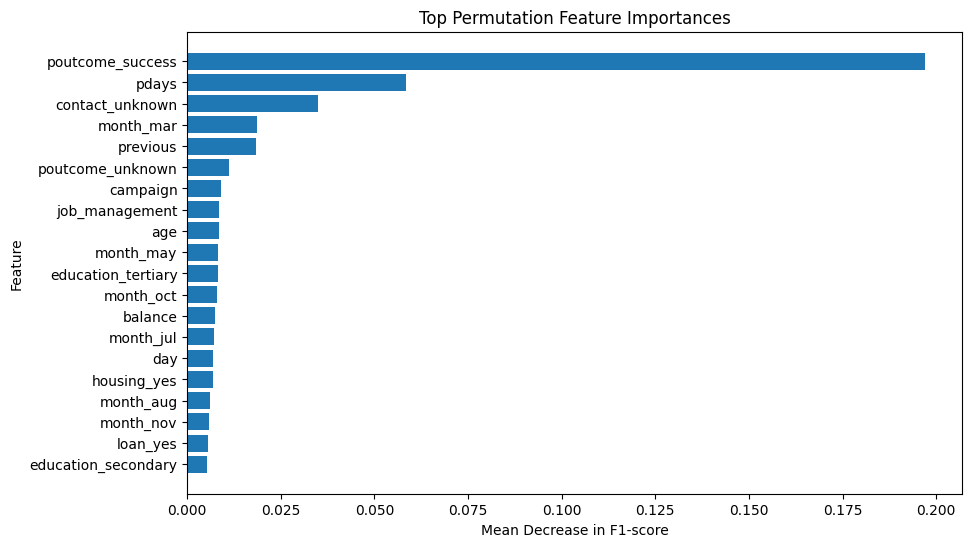

In [45]:
plt.figure(figsize=(10, 6))
plt.barh(top_comparison["Feature"], top_comparison["PFI_Mean_Importance"])
plt.xlabel("Mean Decrease in F1-score")
plt.ylabel("Feature")
plt.title("Top Permutation Feature Importances")
plt.gca().invert_yaxis()
plt.show()

When comparing PFI with the traditional Random Forest feature importance from Task 3, the rankings are different. In Task 3, the highest impurity-based feature importances were `balance`, `age`, and `day`. However, in the PFI results, these features have much lower importance values. For example, `balance` had the highest traditional Random Forest importance, but its PFI value is only approximately 0.007.

This difference happens because the two methods measure importance differently. Traditional Random Forest feature importance measures how much each feature reduced impurity across the trees during training. PFI instead measures how much the trained model’s performance drops when a feature is shuffled on unseen test data. Since F1-score was used for PFI, the PFI ranking emphasises features that are important for predicting the minority class, `y = yes`.

The standard deviation values show how stable the PFI estimates were across repeated shuffles. For example, `poutcome_success` has a low standard deviation compared with its mean importance, meaning that its importance was consistent across the repeated permutations. However, the PFI results should still be interpreted carefully because `pdays` and `poutcome_unknown` are strongly correlated, so their individual PFI values may be affected by shared information. Also, because categorical variables were one-hot encoded, PFI was applied to each dummy column individually. This means that a feature such as `month_mar` represents the importance of the March indicator column, not the whole original `month` variable.

## Model-Agnostic Interpretation Methods

### Partial Dependence Plots 

Partial Dependence Plots were used to understand how selected important features affect the Random Forest model’s average predicted probability of `y = yes`.

I selected `poutcome_success` and `contact_unknown` because they were among the most important features according to Permutation Feature Importance. They were also suitable for PDP interpretation because they were not strongly correlated with each other in the collinearity check. Since both variables are one-hot encoded, their PDPs are interpreted by comparing the model’s average predicted probability when the category is absent (`0`) and when the category is present (`1`). Therefore, the PDP plots are used mainly to compare the two possible states of each feature, rather than to show a smooth continuous trend as would be done for numerical variables such as `age` or `balance`.

In [46]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

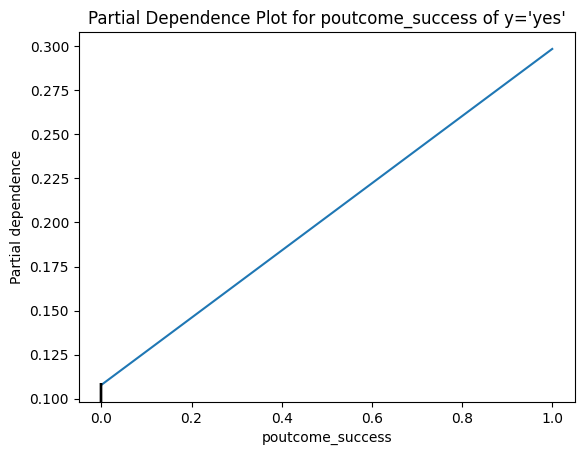

In [47]:
PartialDependenceDisplay.from_estimator(random_forest_model, X_test_cls, features=["poutcome_success"], target=1)

plt.title("Partial Dependence Plot for poutcome_success of y='yes'")
plt.show()

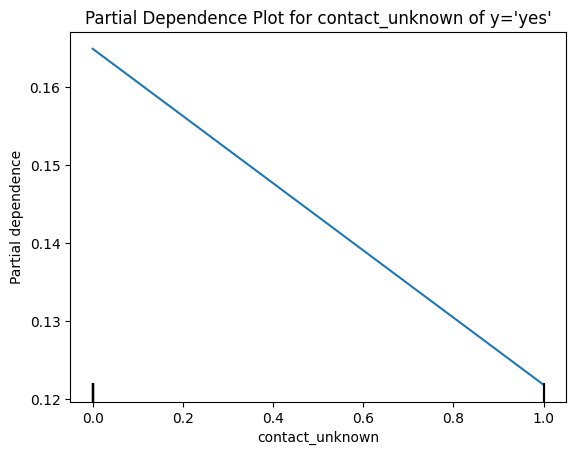

In [48]:
PartialDependenceDisplay.from_estimator(random_forest_model, X_test_cls, features=["contact_unknown"], target=1)

plt.title("Partial Dependence Plot for contact_unknown of y='yes'")
plt.show()

The Partial Dependence Plots show how the Random Forest model’s average predicted probability of `y = yes` changes when the selected feature changes. Unlike feature importance, which tells us which features are important to the model, PDPs show the direction of the model’s behaviour.

For `poutcome_success`, the PDP shows a clear increase in the model’s average predicted probability of `y = yes`. When `poutcome_success = 0`, the average predicted probability is around `0.11`. When `poutcome_success = 1`, the average predicted probability increases to around `0.30`. This means that when the previous campaign outcome was successful, the Random Forest gives a much higher average probability that the client will subscribe to a term deposit. Therefore, the model treats previous campaign success as a positive signal for predicting `y = yes`.

For `contact_unknown`, the PDP shows the opposite behaviour. When `contact_unknown = 0`, the average predicted probability of `y = yes` is around `0.165`. When `contact_unknown = 1`, the average predicted probability decreases to around `0.122`. This means that when the contact method is unknown, the Random Forest gives a lower average probability that the client will subscribe. Therefore, the model treats an unknown contact method as a negative signal for predicting `y = yes`.

Overall, the PDPs help interpret the Random Forest model’s behaviour by showing how important features affect the model’s average prediction. The earlier feature importance methods showed that `poutcome_success` and `contact_unknown` were important, but they did not show whether these features increased or decreased the prediction. The PDPs fill this gap: `poutcome_success` increases the average predicted probability of `y = yes`, while `contact_unknown` decreases it.

A limitation of PDP is that it shows an average effect across the dataset, so it may hide different behaviours for individual clients. Since these features are one-hot encoded, the results should be interpreted as the effect of a specific category being absent or present, rather than the effect of the whole original categorical variable.

### Accumulated Local Effects Plots

In [49]:
from alibi.explainers import ALE, plot_ale
import matplotlib.pyplot as plt

Accumulated Local Effects plots were used as another model-agnostic method to interpret the Random Forest model’s behaviour. ALE is related to PDP because both methods show how selected features affect the model’s prediction. However, they do this in different ways.

PDP shows the model’s average predicted probability when a feature is set to different values across the dataset. This is useful, but it can be less reliable when the selected feature is correlated with other explanatory variables, because changing one feature independently may create unrealistic feature combinations.

ALE addresses this limitation by measuring local changes in the model prediction within intervals where observations actually exist. Instead of forcing a feature to take values across the whole dataset, ALE looks at how the prediction changes locally and then accumulates those local effects. This makes ALE useful for interpreting features where correlation may affect PDP interpretation.

I will be using `poutcome_success` and `contact_unknown` again so that the ALE results could be compared directly with the PDP results. I also will include `pdays` because it was highly ranked by PFI and is a numerical feature, making it suitable for ALE’s interval-based interpretation. Since `pdays` is strongly correlated with `poutcome_unknown`, ALE is especially useful here because it focuses on local effects in regions where real observations exist.

In [50]:
feature_names = list(X_test_cls.columns)
target_names = ["No", "Yes"]

In [51]:
'''
    Alibi passes data as NumPy arrays, while the random forest was trained with dataframe feature names. This wrapper restores the feature names before calling predict_proba(), 
    so ALE explains the predicted probabilities correctly.
'''
def proba_fun_rf(X):
    X_df = pd.DataFrame(X, columns=feature_names)
    return random_forest_model.predict_proba(X_df)

In [52]:
rf_ale = ALE(proba_fun_rf, feature_names=feature_names, target_names=target_names)
rf_ale_exp = rf_ale.explain(X_test_cls.values)

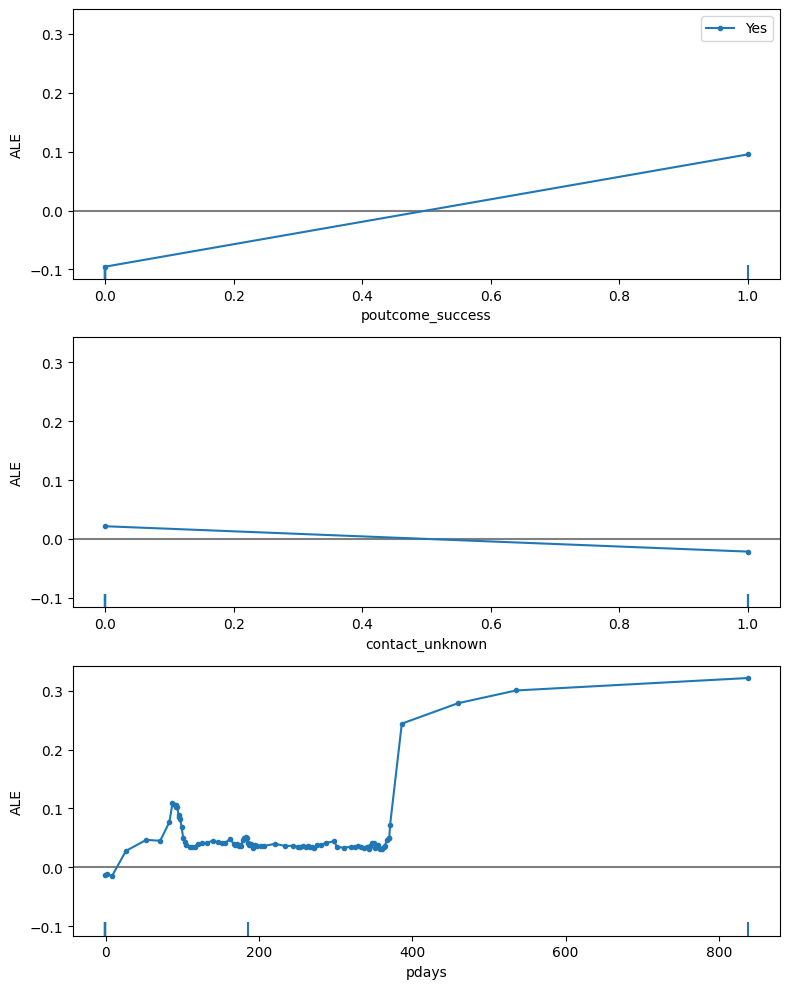

In [53]:
plot_ale(rf_ale_exp, features=["poutcome_success", "contact_unknown", "pdays"], targets=["Yes"], n_cols=1, fig_kw={"figwidth": 8, "figheight": 10})

plt.show()

The Accumulated Local Effects plots show how selected features affect the Random Forest model’s predicted probability of `y = yes` relative to the model’s average prediction. This is different from PDP. In a PDP, the y-axis represents the model’s average predicted probability when a feature is set to different values. In an ALE plot, the y-axis represents the accumulated effect of the feature compared with the model’s average prediction. Therefore, ALE values above `0` mean that the feature value increases the predicted probability of `y = yes` relative to the average prediction, while ALE values below `0` mean that the feature value decreases the predicted probability relative to the average prediction.

For the one-hot encoded features, `poutcome_success` and `contact_unknown`, the ALE plots are interpreted by comparing the effect when the category is absent (`0`) and when the category is present (`1`). Since these features are binary, the ALE plot mainly shows the effect of moving from `0` to `1`, rather than showing a continuous trend like it would for a numerical feature. This is important because the Random Forest was trained on one-hot encoded variables, so the interpretation refers to the specific dummy column, not the whole original categorical variable. For example, `poutcome_success` represents whether the previous campaign outcome was successful, not the full `poutcome` variable.

For `poutcome_success`, the ALE plot shows a clear increase from approximately `-0.10` when `poutcome_success = 0` to approximately `+0.095` when `poutcome_success = 1`. This means that the absence of previous campaign success lowers the model’s predicted probability of `y = yes` relative to the average prediction, while the presence of previous campaign success increases it. This agrees with the PDP result, where the average predicted probability of `y = yes` increased when `poutcome_success` changed from absent to present. Therefore, both PDP and ALE show that the Random Forest treats previous campaign success as a positive signal for predicting subscription.

For `contact_unknown`, the ALE plot shows a decrease from approximately `+0.02` when `contact_unknown = 0` to approximately `-0.02` when `contact_unknown = 1`. This means that a non-unknown contact method slightly increases the model’s prediction relative to the average, while an unknown contact method decreases it. This agrees with the PDP result, where the average predicted probability decreased when `contact_unknown = 1`. Therefore, both PDP and ALE show that the Random Forest treats an unknown contact method as a negative signal for predicting subscription.

For `pdays`, the ALE plot gives a more detailed interpretation because `pdays` is a numerical feature. At very low values of `pdays`, the ALE effect is close to zero or slightly negative, meaning that these values do not strongly increase the model’s prediction. As `pdays` increases, the ALE effect becomes positive and rises gradually. The plot shows a noticeable increase in the higher `pdays` range, where the ALE effect reaches approximately `+0.30`. This means that larger `pdays` values increase the model’s predicted probability of `y = yes` relative to the average prediction. Therefore, the Random Forest treats certain larger values of `pdays` as a positive signal for subscription.

The `pdays` feature is especially useful to interpret with ALE because it was strongly correlated with `poutcome_unknown`. A PDP could still be generated for `pdays`, but its interpretation may be less reliable because PDP changes the selected feature independently across the dataset. When features are correlated, this can create unrealistic feature combinations. ALE reduces this problem by measuring local changes within intervals where observations actually exist. Therefore, ALE is more suitable than PDP for interpreting `pdays` in this case, because it gives a local-effect interpretation while reducing the risk of relying on unrealistic combinations.

Overall, the ALE plots support the PDP findings for the two one-hot encoded features. Both methods show that `poutcome_success` increases the model’s prediction for `y = yes`, while `contact_unknown` decreases it. However, ALE adds an important advantage because it explains local changes in the model’s prediction and is more suitable when feature correlation is a concern. This is particularly useful for `pdays`, where ALE shows how the model’s prediction changes across different value ranges while accounting more carefully for the structure of the observed data.

There are also some limitations to consider. First, ALE depends on how the feature values are divided into intervals. For a numerical feature such as `pdays`, the shape of the curve can change slightly if different bin boundaries are used, especially in sparse regions where there are fewer observations. Second, the ALE plots shown here are one-dimensional, meaning they explain the individual effect of each selected feature, but they do not show interactions between features, such as how `pdays` and `poutcome_success` may work together. Third, for one-hot encoded features such as `poutcome_success` and `contact_unknown`, ALE only compares two values: `0` and `1`. Therefore, ALE does not show a detailed continuous effect for these binary features. Its advantage is clearer for numerical features such as `pdays`, where the plot can show how the model prediction changes across different value ranges.

### Global Surrogate Models

In [54]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import rel_entr

To fit the global surrogate model, I used the Random Forest’s predictions as the target labels, because the goal of the surrogate is to imitate the Random Forest rather than to learn the original target variable directly.

However, I did not want to train and evaluate the surrogate on the same data. If the surrogate Decision Tree was fitted and tested on the same instances, the performance results could look too optimistic because the surrogate would be evaluated on data it had already seen.

For this reason, I split the Random Forest test set into a surrogate training set and a surrogate test set. The surrogate training set was used to train the Decision Tree to copy the Random Forest’s predictions, while the surrogate test set was used to evaluate how well the surrogate approximated the Random Forest on unseen instances.

This means the workflow is: `Random Forest test data → split into surrogate train/test → Random Forest predictions used as surrogate labels → train surrogate on surrogate train set → evaluate surrogate on surrogate test set`

This makes the surrogate evaluation more reliable because the performance metrics measure how well the simpler model generalises when approximating the Random Forest’s behaviour, rather than how well it memorises the data used to fit it.

In [55]:
X_surrogate_train, X_surrogate_test = train_test_split(X_test_cls, test_size=0.3, random_state=42, stratify=random_forest_model.predict(X_test_cls))

In [56]:
rf_predictions_train = random_forest_model.predict(X_surrogate_train)
rf_predictions_test = random_forest_model.predict(X_surrogate_test)

In [57]:
surrogate_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_tree.fit(X_surrogate_train, rf_predictions_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [58]:
surrogate_predictions = surrogate_tree.predict(X_surrogate_test)

In [59]:
rf_predictions = random_forest_model.predict(X_surrogate_test)

KL-divergence was used as the main performance measure because the purpose of a global surrogate model is to approximate the behaviour of the Random Forest, not only to match its final class predictions. If only final class labels are compared, two models may appear to agree even when they assign very different probabilities to the classes. 

For example, both models may predict `No`, but the Random Forest may be highly confident while the surrogate may be uncertain. KL-divergence is useful because it compares the full predicted class probability distributions of the Random Forest and the surrogate model. 

In [60]:
rf_predictions_prob = random_forest_model.predict_proba(X_surrogate_test)
surrogate_predictions_prob = surrogate_tree.predict_proba(X_surrogate_test)

# Small value to avoid log(0) problems
epsilon = 1e-10

rf_probabilities = np.clip(rf_predictions_prob, epsilon, 1)
surrogate_probabilities = np.clip(surrogate_predictions_prob, epsilon, 1)

#Re-normalising after clipping so each row still sums to 1
rf_probabilities = rf_probabilities / rf_probabilities.sum(axis=1, keepdims=True)
surrogate_probabilities = surrogate_probabilities / surrogate_probabilities.sum(axis=1, keepdims=True)

#KL divergence per instance: KL(Random Forest || Surrogate)
kl_values = np.sum(rel_entr(rf_probabilities, surrogate_probabilities), axis=1)

#Average KL divergence across all test instances
mean_kl_divergence = np.mean(kl_values)

print("Mean KL-Divergence:", mean_kl_divergence)

Mean KL-Divergence: 0.21819701019672091


The mean KL-divergence was approximately `0.218`. Since this value is above zero, the surrogate is not a perfect copy of the Random Forest. However, it still provides a useful approximation because it captures part of the Random Forest’s probability behaviour while remaining much simpler and easier to interpret. 

In [61]:
surrogate_conf_matrix = confusion_matrix(rf_predictions, surrogate_predictions)

surrogate_conf_matrix_df = pd.DataFrame(surrogate_conf_matrix, index=["RF Predicted No", "RF Predicted Yes"], columns=["Surrogate Predicted No", "Surrogate Predicted Yes"])
surrogate_conf_matrix_df

,Surrogate Predicted No,Surrogate Predicted Yes
RF Predicted No,2591,12
RF Predicted Yes,44,66


The confusion matrix was also inspected as a supporting check to see how well the surrogate copied the Random Forest’s final class predictions. The surrogate matched most of the Random Forest’s `No` predictions, with `2591` cases where both models predicted `No`. It also matched `66` cases where both models predicted `Yes`. However, there were `44` cases where the Random Forest predicted `Yes` but the surrogate predicted `No`, and `12` cases where the Random Forest predicted `No` but the surrogate predicted `Yes`. This shows that the surrogate agrees with the Random Forest for most final predictions, especially for the majority `No` class, but it does not perfectly reproduce the Random Forest’s behaviour for all cases.

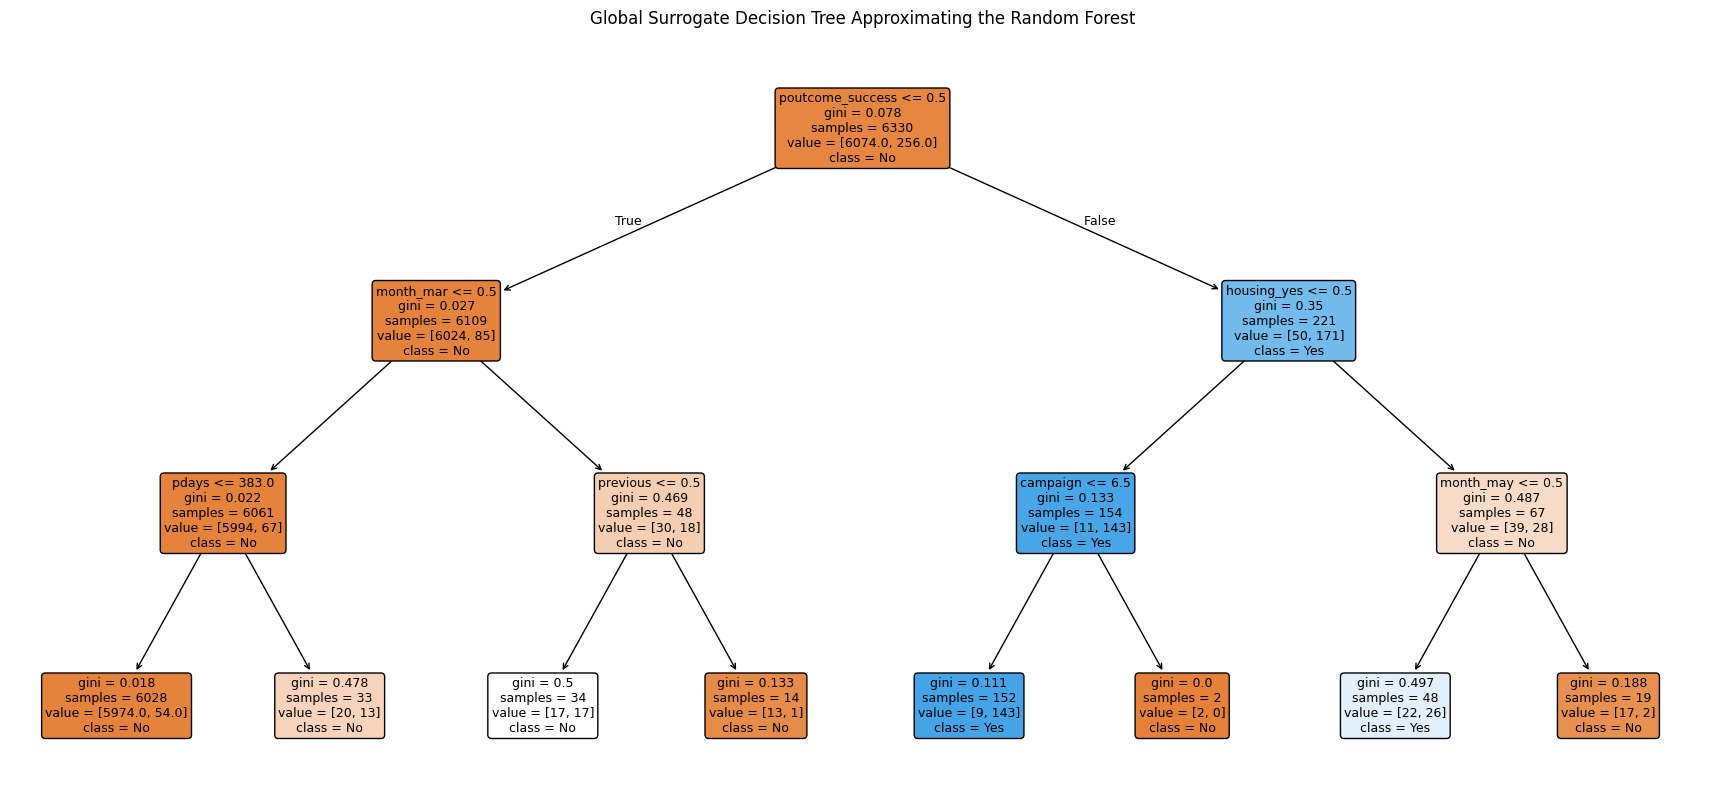

In [62]:
plt.figure(figsize=(22, 10))

plot_tree(surrogate_tree, feature_names=X_test_cls.columns, class_names=["No", "Yes"], filled=True, rounded=True, fontsize=9)

plt.title("Global Surrogate Decision Tree Approximating the Random Forest")
plt.show()

In [63]:
surrogate_feature_importance = pd.DataFrame({"Feature": X_test_cls.columns, "Importance": surrogate_tree.feature_importances_})

surrogate_feature_importance = surrogate_feature_importance.sort_values(by="Importance", ascending=False)
surrogate_feature_importance.head(10)

,Feature,Importance
39,poutcome_success,0.806693
23,housing_yes,0.079758
33,month_mar,0.041323
4,pdays,0.031866
34,month_may,0.016982
5,previous,0.011932
3,campaign,0.011446
30,month_jan,0.000000
24,loan_yes,0.000000
25,contact_telephone,0.000000


The global surrogate model helps interpret the Random Forest by approximating its behaviour using a simpler Decision Tree. Since the Random Forest is made up of many trees, it is difficult to follow one clear decision path. The surrogate tree simplifies this by showing an approximate set of rules that explain how the Random Forest tends to make its predictions.

The root node of the surrogate tree splits on `poutcome_success`, meaning that previous campaign success is the first and most important condition used by the surrogate to approximate the Random Forest. Since `poutcome_success` is one-hot encoded, `poutcome_success <= 0.5` means that the previous campaign outcome was not successful, while `poutcome_success > 0.5` means that the previous campaign outcome was successful.

On the left side of the tree, where `poutcome_success <= 0.5`, the surrogate mostly predicts `No`. This suggests that the Random Forest generally treats the absence of previous campaign success as a strong signal against subscription. Within this branch, the surrogate further checks `month_mar`, `pdays`, and `previous`. These features refine the prediction, but most paths in this side of the tree still lead to `No`. This shows that when there was no previous campaign success, the Random Forest’s behaviour is mostly oriented towards predicting non-subscription, with previous contact timing and March contact status only adjusting the decision slightly.

On the right side of the tree, where `poutcome_success > 0.5`, the surrogate moves towards branches where `Yes` is more likely. This means that the Random Forest tends to treat previous campaign success as a strong positive signal for subscription. In this branch, the surrogate then checks `housing_yes`. If `housing_yes <= 0.5`, meaning the client does not have a housing loan, the tree then uses `campaign <= 6.5` to refine the prediction, and this path mostly leads to `Yes`. This suggests that the Random Forest is more likely to predict subscription when the client had a previous successful campaign outcome, does not have a housing loan, and was not contacted too many times in the current campaign.

The tree also uses `month_may` on the right side. In that part of the tree, the surrogate distinguishes between clients contacted in May and clients not contacted in May. This suggests that, after previous campaign success and housing loan status have been considered, the month of contact still helps refine the Random Forest’s prediction behaviour.

I also examined the surrogate feature importance values to support the interpretation of the tree structure. These values show which features the surrogate relied on most when approximating the Random Forest’s predictions. `poutcome_success` has the highest importance by far, with an importance value of approximately `0.807`. This confirms that most of the surrogate’s simplified explanation depends on previous campaign success. The next most important features are `housing_yes`, `month_mar`, `pdays`, `month_may`, `previous`, and `campaign`, but their importance values are much smaller. This shows that these features help refine the Random Forest approximation, while `poutcome_success` remains the dominant feature.

Overall, the surrogate suggests that the Random Forest’s behaviour can be approximately summarised as follows: previous campaign success is the strongest signal. If previous campaign success is absent, the model mostly predicts `No`. If previous campaign success is present, the model becomes much more likely to predict `Yes`, especially when the client does not have a housing loan and the number of current campaign contacts is not too high. Therefore, the global surrogate helps interpret the Random Forest by converting the complex behaviour of many trees into a smaller set of readable decision rules.

However, the surrogate should not be treated as a perfect explanation of the Random Forest. It is only an approximation. The Random Forest may use more complex interactions across many trees, while the surrogate Decision Tree only captures the main simplified patterns.

## Local interpretation methods

### LIME

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lime.lime_tabular

In [65]:
class_names = ["No", "Yes"]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train_cls.values, feature_names=list(X_train_cls.columns), class_names=class_names, mode="classification")

In [66]:
rf_test_predictions = random_forest_model.predict(X_test_cls)
rf_test_probabilities = random_forest_model.predict_proba(X_test_cls)

no_idx = np.where(rf_test_predictions == 0)[0][0]
yes_idx = np.where(rf_test_predictions == 1)[0][0]

print("No instance index:", no_idx)
print("Yes instance index:", yes_idx)

print("RF probability for No instance:", rf_test_probabilities[no_idx])
print("RF probability for Yes instance:", rf_test_probabilities[yes_idx])

No instance index: 0
Yes instance index: 7
RF probability for No instance: [1. 0.]
RF probability for Yes instance: [0.18 0.82]


In [67]:
feature_names = list(X_test_cls.columns)

'''
    LIME passes perturbed samples as NumPy arrays. This wrapper restores the original DataFrame feature names before calling predict_proba().
'''
def rf_predict_proba_with_names(X):
    X_df = pd.DataFrame(X, columns=feature_names)
    return random_forest_model.predict_proba(X_df)

In [68]:
lime_no_exp = lime_explainer.explain_instance(data_row=X_test_cls.iloc[no_idx].values, predict_fn=rf_predict_proba_with_names, num_features=10, top_labels=1)
lime_yes_exp = lime_explainer.explain_instance(data_row=X_test_cls.iloc[yes_idx].values, predict_fn=rf_predict_proba_with_names, num_features=10, top_labels=1)

In [69]:
def lime_exp_as_pyplot(exp, label, title, figsize=(8, 5)):
    exp_list = exp.as_list(label=label)

    feature_conditions = [item[0] for item in exp_list]
    contributions = [item[1] for item in exp_list]

    #Reversing list so the largest appears at the top in a horizontal bar plot
    feature_conditions = feature_conditions[::-1]
    contributions = contributions[::-1]

    colors = ["green" if value > 0 else "red" for value in contributions]

    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(len(contributions))

    ax.barh(positions, contributions, color=colors)
    ax.set_yticks(positions)
    ax.set_yticklabels(feature_conditions)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("LIME Contribution")
    ax.set_title(title)

    plt.tight_layout()
    return fig, ax

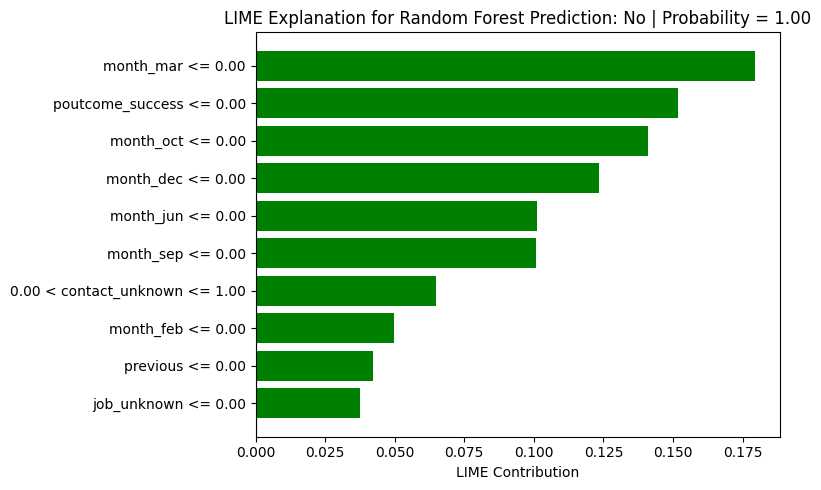

In [70]:
lime_exp_as_pyplot(lime_no_exp, label=0, title=f"LIME Explanation for Random Forest Prediction: No | Probability = {rf_test_probabilities[no_idx][0]:.2f}")
plt.show()

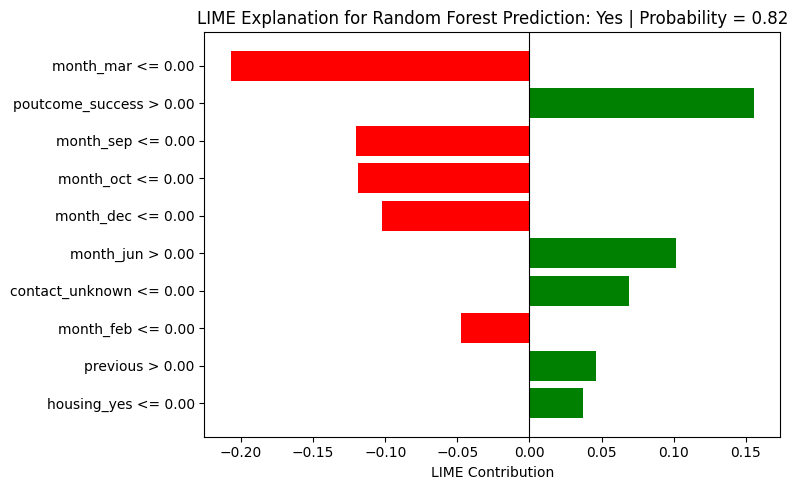

In [71]:
lime_exp_as_pyplot(lime_yes_exp, label=1, title=f"LIME Explanation for Random Forest Prediction: Yes | Probability = {rf_test_probabilities[yes_idx][1]:.2f}")
plt.show()

In [72]:
lime_no_table = pd.DataFrame(lime_no_exp.as_list(label=0), columns=["Feature condition", "Contribution"])
lime_yes_table = pd.DataFrame(lime_yes_exp.as_list(label=1),columns=["Feature condition", "Contribution"])

In [73]:
lime_no_table

,Feature condition,Contribution
0,month_mar <= 0.00,0.179470
1,poutcome_success <= 0.00,0.151745
2,month_oct <= 0.00,0.140951
3,month_dec <= 0.00,0.123385
4,month_jun <= 0.00,0.101069
5,month_sep <= 0.00,0.100620
6,0.00 < contact_unknown <= 1.00,0.064861
7,month_feb <= 0.00,0.049690
8,previous <= 0.00,0.042130
9,job_unknown <= 0.00,0.037467


In [74]:
lime_yes_table

,Feature condition,Contribution
0,month_mar <= 0.00,-0.207172
1,poutcome_success > 0.00,0.155536
2,month_sep <= 0.00,-0.120330
3,month_oct <= 0.00,-0.118538
4,month_dec <= 0.00,-0.102569
5,month_jun > 0.00,0.101475
6,contact_unknown <= 0.00,0.068711
7,month_feb <= 0.00,-0.047231
8,previous > 0.00,0.046248
9,housing_yes <= 0.00,0.036847


For the LIME analysis, I selected two individual test instances: one instance predicted as `No` and one instance predicted as `Yes` by the Random Forest. This was done to give variety in the local interpretation, so that the explanation shows how features contribute to both types of predictions. The LIME results were visualised using bar plots because this makes it easier to see which feature conditions pushed the prediction towards or away from the predicted class. I also displayed the results as tables so that the exact feature conditions and contribution values could be read clearly.

For the first instance, the Random Forest predicted `No` with probability `1.00`. In the LIME explanation for the `No` class, all of the displayed feature contributions are positive. This means that the strongest local feature conditions all supported the `No` prediction. The largest contribution came from `month_mar <= 0.00`, with a contribution of approximately `0.206`. Since `month_mar` is one-hot encoded, this means that the client was not contacted in March, and for this individual prediction this condition pushed the model towards `No`.

The second strongest contribution was `poutcome_success <= 0.00`, with a contribution of approximately `0.156`. This means that the previous campaign outcome was not successful, which also strongly pushed the model towards predicting `No`. Other month-related conditions such as `month_sep <= 0.00`, `month_oct <= 0.00`, `month_dec <= 0.00`, and `month_jun <= 0.00` also contributed towards `No`. In addition, `previous <= 0.00` shows that having no previous contacts supported the `No` prediction. Overall, for this instance, the important feature conditions all worked in the same direction, which explains why the Random Forest predicted `No` with very high confidence.

For the second instance, the Random Forest predicted `Yes` with probability `0.82`. In this explanation, the feature contributions are mixed. Some feature conditions supported the `Yes` prediction, while others pushed against it. The strongest positive contribution was `poutcome_success > 0.00`, with a contribution of approximately `0.154`. This means that the client had a successful previous campaign outcome, and this was the strongest feature pushing the model towards predicting `Yes`.

Other features also supported the `Yes` prediction. `month_jun > 0.00` contributed approximately `0.099`, meaning that being contacted in June pushed the model towards `Yes` for this instance. `contact_unknown <= 0.00` also contributed positively, meaning that the contact method was known, which supported the `Yes` prediction. The conditions `previous > 0.00` and `housing_yes <= 0.00` also pushed the prediction towards `Yes`, meaning that having previous contacts and not having a housing loan helped support the subscription prediction for this specific client.

However, not all features supported the `Yes` prediction. The strongest negative contribution was `month_mar <= 0.00`, with a contribution of approximately `-0.217`. This means that not being contacted in March pushed against the `Yes` prediction. Other negative contributions included `month_oct <= 0.00`, `month_dec <= 0.00`, `month_sep <= 0.00`, and `month_feb <= 0.00`. These features reduced support for `Yes`, but the Random Forest still predicted `Yes` because the positive contributions, especially `poutcome_success > 0.00`, were strong enough to outweigh the negative ones.

Overall, the LIME explanations show how individual predictions are formed from local feature contributions. For the `No` instance, the strongest feature conditions all supported the predicted label, making the prediction very confident. For the `Yes` instance, the prediction was based on a balance of positive and negative contributions, where previous campaign success was the strongest feature supporting the final `Yes` prediction.

### SHAP

In [75]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

SHAP was applied to the same two individual instances used in the LIME analysis so that the explanations could be compared directly. The first instance was predicted as `No`, so SHAP values for class `No` were used. The second instance was predicted as `Yes`, so SHAP values for class `Yes` were used.

In [95]:
shap_instances = X_test_cls.iloc[[no_idx, yes_idx]]
shap_instances

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
1392,40,640,8,2,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
43965,64,109,23,1,225,2,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False


In [93]:
shap_explainer = shap.TreeExplainer(random_forest_model)
shap_values = shap_explainer(shap_instances)

In [79]:
print("SHAP values shape:", shap_values.values.shape)
print("Base values shape:", np.array(shap_values.base_values).shape)
print("Model probabilities:")
print(random_forest_model.predict_proba(shap_instances))

SHAP values shape: (2, 41, 2)
Base values shape: (2, 2)
Model probabilities:
[[1.   0.  ]
 [0.18 0.82]]


In [86]:
shap_no_exp = shap.Explanation(values=shap_values.values[0, :, 0], base_values=shap_values.base_values[0, 0], data=shap_instances.iloc[0].values, feature_names=list(X_test_cls.columns))
shap_yes_exp = shap.Explanation( values=shap_values.values[1, :, 1], base_values=shap_values.base_values[1, 1], data=shap_instances.iloc[1].values, feature_names=list(X_test_cls.columns))

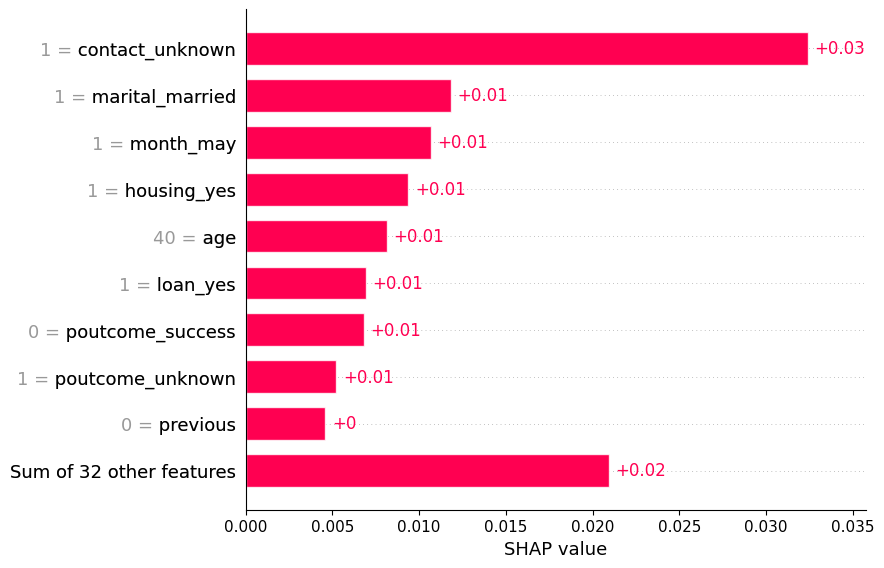

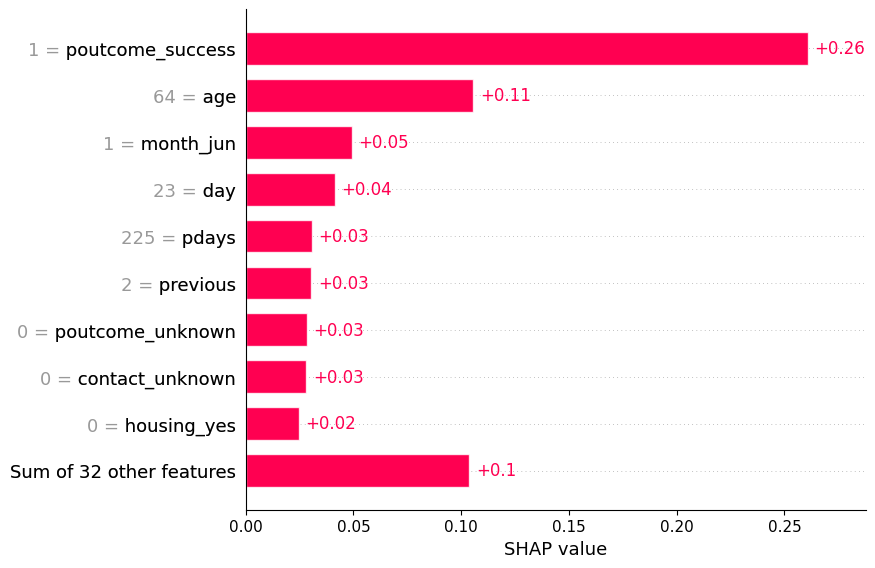

In [94]:
shap.plots.bar(shap_no_exp, max_display=10)
shap.plots.bar(shap_yes_exp, max_display=10)

In [ ]:
def shap_contribution_table(shap_exp, top_n=10):
    table = pd.DataFrame({"Feature": shap_exp.feature_names, "Feature value": shap_exp.data, "SHAP contribution": shap_exp.values, "Absolute contribution": np.abs(shap_exp.values)})

    return table.sort_values(by="Absolute contribution", ascending=False).head(top_n)

In [89]:
shap_no_table = shap_contribution_table(shap_no_exp, top_n=10)
shap_no_table

,Feature,Feature value,SHAP contribution,Absolute contribution
26,contact_unknown,True,0.032425,0.032425
17,marital_married,True,0.011841,0.011841
34,month_may,True,0.010659,0.010659
23,housing_yes,True,0.009381,0.009381
0,age,40,0.008153,0.008153
24,loan_yes,True,0.006916,0.006916
39,poutcome_success,False,0.006810,0.006810
40,poutcome_unknown,True,0.005224,0.005224
5,previous,0,0.004587,0.004587
18,marital_single,False,0.003909,0.003909


In [ ]:
shap_yes_table = shap_contribution_table(shap_yes_exp, top_n=10)
shap_yes_table

,Feature,Feature value,SHAP contribution,Absolute contribution
39,poutcome_success,True,0.260954,0.260954
0,age,64,0.105674,0.105674
32,month_jun,True,0.049146,0.049146
2,day,23,0.041359,0.041359
4,pdays,225,0.030691,0.030691
5,previous,2,0.030498,0.030498
40,poutcome_unknown,False,0.028333,0.028333
26,contact_unknown,False,0.028095,0.028095
23,housing_yes,False,0.024543,0.024543
3,campaign,1,0.020674,0.020674


#### SHAP Interpretation of Individual Predictions

For the first instance, the Random Forest predicted `No`. Therefore, the SHAP explanation was interpreted for the `No` class. The largest SHAP contribution came from `contact_unknown = True`, with a contribution of approximately `0.032`. This means that, for this specific client, having an unknown contact method pushed the prediction towards `No`. The next strongest contributors were `marital_married = True`, `month_may = True`, `housing_yes = True`, and `age = 40`. These features also had positive SHAP values, meaning that they increased the model’s support for the `No` prediction.

Other smaller positive contributions came from `loan_yes = True`, `poutcome_success = False`, `poutcome_unknown = True`, and `previous = 0`. These conditions also pushed the model towards `No`, but with weaker effects. Overall, the SHAP explanation shows that this `No` prediction was supported by several feature values, especially unknown contact method, May contact month, housing loan status, and the absence of previous campaign success.

For the second instance, the Random Forest predicted `Yes`. Therefore, the SHAP explanation was interpreted for the `Yes` class. The strongest contribution was `poutcome_success = True`, with a SHAP contribution of approximately `0.261`. This means that previous campaign success was the main feature pushing the model towards predicting subscription for this client.

Other important positive SHAP contributions included `age = 64`, with a contribution of approximately `0.106`, `month_jun = True`, with approximately `0.049`, and `day = 23`, with approximately `0.041`. The features `pdays = 225`, `previous = 2`, `poutcome_unknown = False`, `contact_unknown = False`, `housing_yes = False`, and `campaign = 1` also pushed the prediction towards `Yes`. This suggests that, for this individual client, previous campaign success, older age, previous contact history, known contact method, no housing loan, and a low number of current campaign contacts all contributed towards the Random Forest predicting subscription.

Overall, the SHAP explanations show which features contributed most to each individual Random Forest prediction. For the `No` instance, the strongest support came from contact and campaign-related conditions that pushed the model towards non-subscription. For the `Yes` instance, the prediction was mainly driven by `poutcome_success = True`, with additional support from age, contact history, timing, and loan-related features.

#### SHAP vs LIME

The SHAP and LIME explanations were applied to the same two individual Random Forest predictions, so their results can be compared directly. LIME explains a prediction by fitting a simple local surrogate model around the selected instance, while SHAP assigns contribution values to features based on how much they move the prediction away from the baseline.

For the `No` instance, both methods identified features related to campaign/contact history and timing as important. LIME showed that `poutcome_success <= 0.00`, `previous <= 0.00`, `contact_unknown`, and several month indicators supported the `No` prediction. SHAP also identified related features, including `contact_unknown = True`, `poutcome_success = False`, `poutcome_unknown = True`, and `previous = 0`. Therefore, both methods agree that the absence of previous campaign success and previous contact information contributed to the `No` prediction. However, the ranking was different: LIME gave the largest contribution to `month_mar <= 0.00`, while SHAP gave the largest contribution to `contact_unknown = True`.

For the `Yes` instance, the agreement between LIME and SHAP is clearer. Both methods identified `poutcome_success = True` as one of the strongest reasons for predicting `Yes`. LIME showed `poutcome_success > 0.00` as the strongest positive contribution, while SHAP also ranked `poutcome_success = True` as the largest contribution by far. Both methods also showed that `month_jun`, known contact method, previous campaign/contact history, and no housing loan supported the `Yes` prediction.

There were also some differences. LIME showed both positive and negative local contributions for the `Yes` instance. For example, some month-related conditions pushed against the `Yes` prediction. In contrast, the displayed SHAP table for the `Yes` instance mainly shows the strongest positive contributors towards `Yes`. SHAP also highlighted additional features such as `age`, `day`, `pdays`, and `campaign`, which were less central in the LIME explanation.

Overall, SHAP and LIME gave broadly consistent explanations for the main prediction drivers, especially for the `Yes` instance where both methods highlighted previous campaign success as the strongest supporting feature. The differences in feature ranking are expected because LIME uses a local surrogate approximation, while SHAP distributes the prediction difference from the baseline across the feature values. Together, the two methods strengthen the local interpretation by showing that the Random Forest’s individual predictions are strongly influenced by campaign outcome, contact information, previous contact history, and timing-related variables.

# Generative AI 

`AI Tool Used`
- For this project, I used **ChatGPT, GPT-5.5 Thinking**.

`How the Tool Was Used`:
- I used GPT-5.5 mainly as a support tool by asking it to act like a specialist in interpretable machine learning. The purpose was to help me reason about my design choices, structure my explanations, and use the correct terminology when discussing the plots, tables, and model interpretation outputs generated in my notebook.

In particular, I used it to help me:
- argue and justify decisions such as which metrics to use for model or surrogate evaluation.
- understand the results and plots produced in my notebook, including feature importance tables, PDP/ALE plots, surrogate trees, LIME explanations, and SHAP contribution tables. I used it to check whether my interpretation of these outputs made sense, not to decide the final analysis for me.
- phrase my discussions more clearly and accurately.
- decide which Python libraries were suitable for specific interpretation methods.
- debug code or warnings when using interpretation libraries.

When code was suggested, I did not treat it as automatically correct. I ran the code in my notebook, checked whether it produced the intended output, and continued asking follow-up questions to confirm whether the implementation matched the approach I wanted to use.


`Some prompts i used`:
```text
"suggest ways on how I should interpret this PDP plot for a one-hot encoded feature."
"this code is outputting a warning because the model was trained with feature names. Give me suggestions of how i should fix it?"
"why is one hot encoding preferred over label encoding when it comes to encoding features? why shouldn’t i use label encoding for jobs marital contact and so on especially since they would contain a large set of elements that each can pick from?"
"i am thinking of using KL-divergence to measure how well my global surrogate model approximates the Random Forest, because i want to compare the predicted probability distributions rather than only the final class labels. Argue against this choice and tell me what weaknesses or alternatives i should consider."
"Re-write this respective discussion that i came up with so that it has more flow, and it is more understandable to what my reasoning is"
"If i want to implement PDP, ALE, LIME, and SHAP for a Random Forest classifier in Python. i think scikit-learn can handle PDP, but i am unsure which libraries are most suitable for ALE, LIME, and SHAP. Challenge my library choices and explain which Python packages and methods would be most appropriate for each interpretation technique, including any limitations i should watch out for."
"I have generated this PDP output from my Random Forest model. Challenge my interpretation of the plot and tell me whether the reasoning makes sense based only on the displayed feature values, contribution scores, and model output."
```

`How the AI Output Was Used`:

Where GPT-5.5 suggested code, I tested it in my notebook and checked that it produced the expected results. If the output did not match the approach I wanted, I asked further questions and adjusted the implementation accordingly. For example, when using libraries such as lime, shap, alibi, and PyALE, I checked whether the suggested methods matched the required interpretation technique and whether the results could be correctly explained.

When GPT-5.5 provided an interpretation or explanation of a result, I applied my own reasoning to check whether the explanation made sense with respect to the actual plot, table, metric value, or feature contribution shown in my notebook. I compared the AI’s explanation with the lecture notes and with the values produced by my code. I then adapted or rejected parts of the response where needed and wrote the final discussion based on my own understanding of the generated results.

Verification of AI Responses:
I treated GPT-5.5 as a probabilistic text-generation tool, not as an authority. Its responses were used as suggestions that needed to be checked. I verified the information by comparing it with the provided lecture notes, the project specification, and the actual outputs produced by my notebook.

I checked that:
- the selected metrics were appropriate for the task being discussed.
- the code ran correctly and produced the required plots, tables, or metric values.
- the rewritten discussion matched my actual outputs rather than generic examples and my intent reasoning.
- one-hot encoded categorical variables were interpreted correctly.
- limitations such as class imbalance, correlated features, and surrogate approximation error were discussed accurately.

Therefore, GPT-5.5 was used to support brainstorming, explanation, wording, library selection, method selection, and implementation debugging, while the final decisions, verification, and project interpretation were based on my own code, results, lecture notes, and understanding.